X shape: (118, 376, 93)
y shape: (118,)
Flattened shape: (118, 34968)
Animate count: 63
Inanimate count: 55
Coefficient vector shape: (34968,)
Intercept: 0.018266050594615106
Weight map shape: (376, 93)


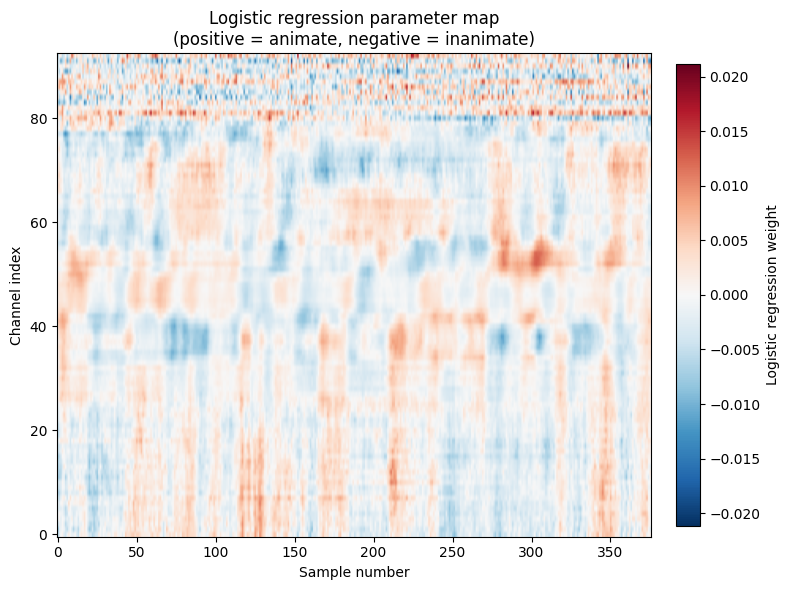

Saved weights to: /home/maria/LFPExperiments/data/logreg_full_fit

Top 20 features by absolute weight:
 1. time=361, channel=90, weight= 0.021211
 2. time=148, channel=91, weight=-0.017671
 3. time= 77, channel=91, weight=-0.017125
 4. time=215, channel=89, weight=-0.016705
 5. time=301, channel=81, weight= 0.016669
 6. time=224, channel=92, weight= 0.016597
 7. time=361, channel=91, weight=-0.016299
 8. time=152, channel=92, weight= 0.015770
 9. time=221, channel=86, weight= 0.015727
10. time=225, channel=92, weight= 0.015582
11. time=371, channel=91, weight=-0.015561
12. time= 59, channel=81, weight= 0.015512
13. time= 90, channel=84, weight=-0.015252
14. time= 63, channel=91, weight=-0.015215
15. time=359, channel=81, weight= 0.015065
16. time=304, channel=81, weight= 0.014841
17. time=284, channel=81, weight= 0.014684
18. time=134, channel=80, weight= 0.014353
19. time=216, channel=89, weight=-0.014339
20. time=125, channel=91, weight=-0.014312


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# ============================================================
# PATHS
# ============================================================

LFP_PATH = "/home/maria/LFPExperiments/data/mean_lfp_by_image.npy"
VIT_PATH = "/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl"
OUT_DIR = "/home/maria/LFPExperiments/data/logreg_full_fit"

os.makedirs(OUT_DIR, exist_ok=True)


# ============================================================
# LOAD DATA
# ============================================================

X = np.load(LFP_PATH)   # shape: (n_images, n_timepoints, n_channels)
vit = np.load(VIT_PATH, allow_pickle=True)["natural_scenes"]

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(np.int64)   # 1 = animate, 0 = inanimate

print("X shape:", X.shape)
print("y shape:", y.shape)

if X.ndim != 3:
    raise ValueError(f"Expected X to have shape (n_images, n_timepoints, n_channels), got {X.shape}")

n_images, n_timepoints, n_channels = X.shape
X_flat = X.reshape(n_images, n_timepoints * n_channels)

print("Flattened shape:", X_flat.shape)
print("Animate count:", y.sum())
print("Inanimate count:", len(y) - y.sum())


# ============================================================
# FIT LOGISTIC REGRESSION ON ALL DATA
# ============================================================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

pipe.fit(X_flat, y)

logreg = pipe.named_steps["logreg"]
scaler = pipe.named_steps["scaler"]

coef = logreg.coef_[0]          # shape: (n_timepoints * n_channels,)
intercept = logreg.intercept_[0]

print("Coefficient vector shape:", coef.shape)
print("Intercept:", intercept)


# ============================================================
# RESHAPE WEIGHTS BACK TO IMAGE FORMAT
# ============================================================

weight_map = coef.reshape(n_timepoints, n_channels)   # (timepoints, channels)

print("Weight map shape:", weight_map.shape)


# ============================================================
# PLOT WEIGHT MAP
# ============================================================

plt.figure(figsize=(8, 6))
vabs = np.max(np.abs(weight_map))

im = plt.imshow(
    weight_map.T,
    aspect='auto',
    origin='lower',
    cmap='RdBu_r',
    vmin=-vabs,
    vmax=vabs
)

plt.colorbar(im, fraction=0.036, pad=0.04, label="Logistic regression weight")
plt.xlabel("Sample number")
plt.ylabel("Channel index")
plt.title("Logistic regression parameter map\n(positive = animate, negative = inanimate)")
plt.tight_layout()
plt.show()


# ============================================================
# SAVE WEIGHTS
# ============================================================

np.save(os.path.join(OUT_DIR, "coef_vector.npy"), coef)
np.save(os.path.join(OUT_DIR, "weight_map.npy"), weight_map)
np.save(os.path.join(OUT_DIR, "intercept.npy"), np.array([intercept]))

print(f"Saved weights to: {OUT_DIR}")


# ============================================================
# PRINT TOP FEATURES
# ============================================================

flat_abs_order = np.argsort(np.abs(coef))[::-1]

print("\nTop 20 features by absolute weight:")
for rank, flat_idx in enumerate(flat_abs_order[:20], start=1):
    t_idx, ch_idx = np.unravel_index(flat_idx, (n_timepoints, n_channels))
    print(
        f"{rank:2d}. time={t_idx:3d}, channel={ch_idx:2d}, "
        f"weight={coef[flat_idx]: .6f}"
    )